# Broadcasting

Visualise how broadcasting stretches a smaller operand to match a larger one. Each operand is drawn in its own shape and again stretched to the common broadcast shape, so the repeated values along a stretched axis are visible. Every stretched axis is marked in the accent colour.

In [1]:
from pprint import pprint

import numpy as np

import rainbow_tensor as rt

## Row and column stretch

A `(3, 1)` column and a `(1, 4)` row broadcast to `(3, 4)`. The column repeats across its single column axis and the row repeats down its single row axis, so together they fill the result.

array([[0],
       [1],
       [2]])
array([[0, 1, 2, 3]])
array([[0, 1, 2, 3],
       [1, 2, 3, 4],
       [2, 3, 4, 5]])


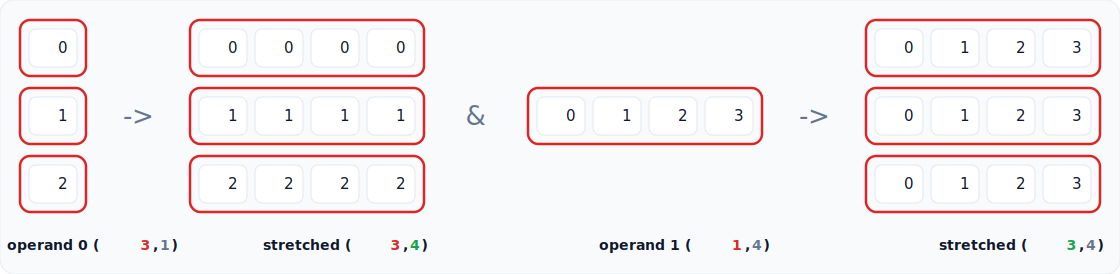

Operand shapes: (3, 1) and (1, 4)
operand 0 (3, 1) stretches axes [1]
operand 1 (1, 4) stretches axes [0]
Result shape: (3, 4)
A stretched axis repeats one value, so both operands fill the result shape.


In [2]:
a = np.arange(3).reshape(3, 1)
b = np.arange(4).reshape(1, 4)
pprint(a)
pprint(b)
pprint(a + b)
rt.broadcast(a, b)

## Adding a leading axis

When one operand has fewer axes the missing leading axes are added and stretched. A `(4,)` vector lines up against a `(2, 3, 4)` tensor by gaining two leading axes.

array([0, 1, 2, 3])
(2, 3, 4)


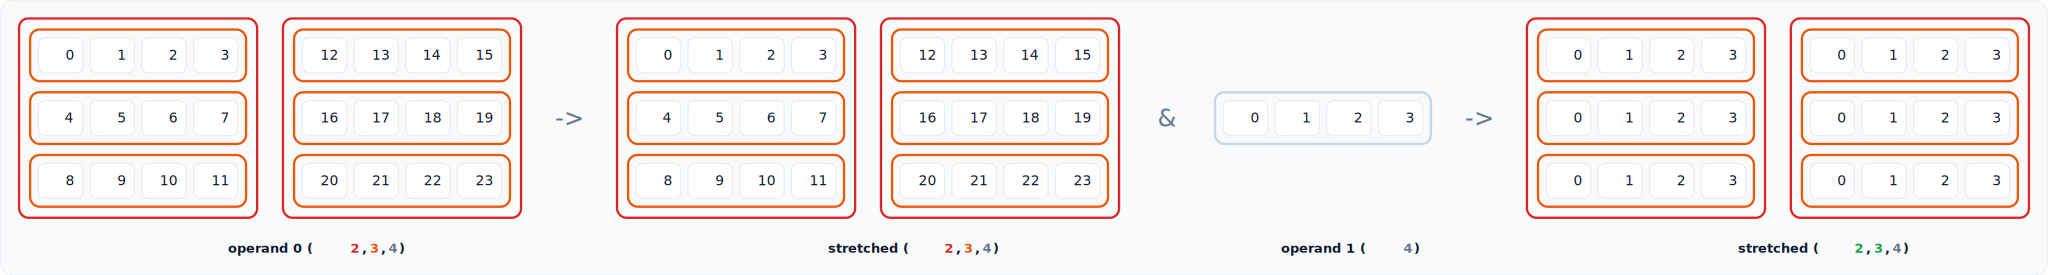

Operand shapes: (2, 3, 4) and (4,)
operand 0 (2, 3, 4) already matches
operand 1 (4,) stretches axes [0, 1]
Result shape: (2, 3, 4)
A stretched axis repeats one value, so both operands fill the result shape.


In [3]:
a = np.arange(24).reshape(2, 3, 4)
b = np.arange(4)
pprint(b)
pprint(np.broadcast_shapes(a.shape, b.shape))
rt.broadcast(a, b)

## Incompatible shapes

When the axes do not line up the call raises a clear error instead of drawing a wrong figure.

In [4]:
try:
    rt.broadcast((3,), (4,))
except ValueError as error:
    print(error)

operands could not be broadcast together: axis sizes [3, 4]


## Dark theme

The figure adapts to the dark theme through `theme="dark"`.

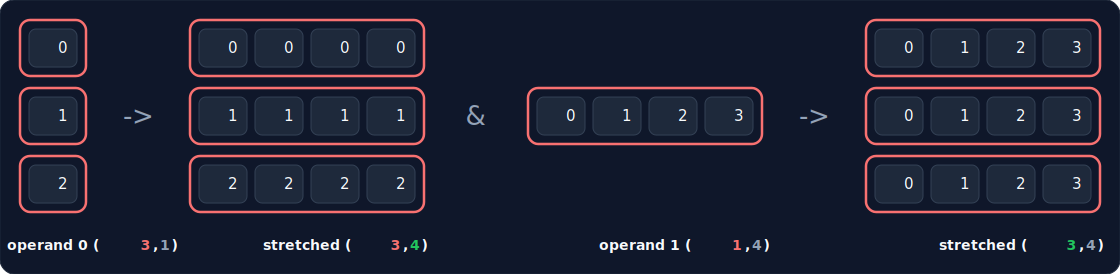

Operand shapes: (3, 1) and (1, 4)
operand 0 (3, 1) stretches axes [1]
operand 1 (1, 4) stretches axes [0]
Result shape: (3, 4)
A stretched axis repeats one value, so both operands fill the result shape.


In [5]:
rt.broadcast((3, 1), (1, 4), theme="dark")